# Исследование новых стратегий поведения ЦБ РФ

В этом ноутбуке строятся графики для **стратегии 5** (фиксированная ставка 13% на всём горизонте) и сравниваются её последствия с базовыми сценариями.

## Подготовка и импорты

In [1]:
import os
import sys

sys.path.append(os.path.abspath('..'))

from plots import (
    plot_key_rate_comparison_4_results,
    plot_losses,
    plot_main_indicators,
)
from policies import (
    build_scenario_1_strategy,
    build_scenario_2_strategy,
    build_scenario_3_strategy,
    build_scenario_4_strategy,
    build_scenario_5_strategy,
)
from simulation import simulate_scenario

## Расчёт сценариев с константной ставкой

Стратегия 5 задаёт постоянную номинальную ставку **13%** на всём горизонте моделирования.

## Сценарий с константной ставкой 9%

В этом блоке ставка фиксирована на уровне **9%** на всём горизонте.

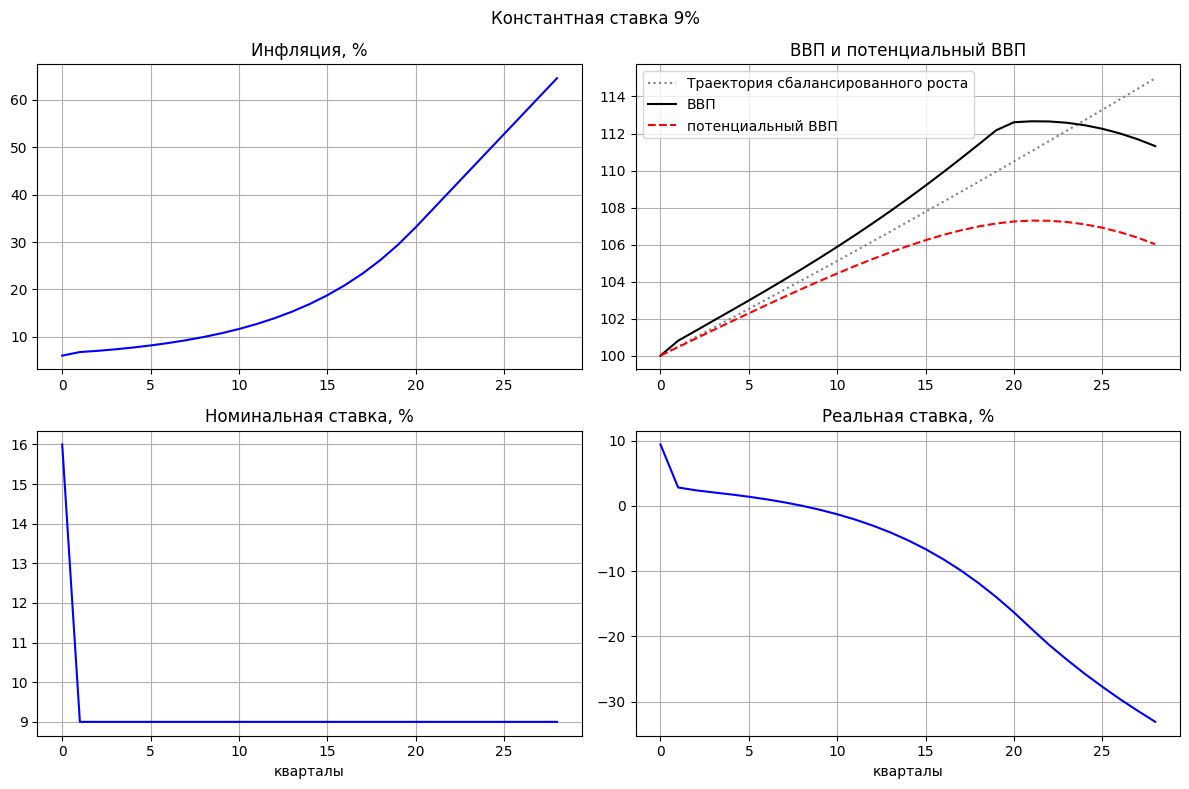

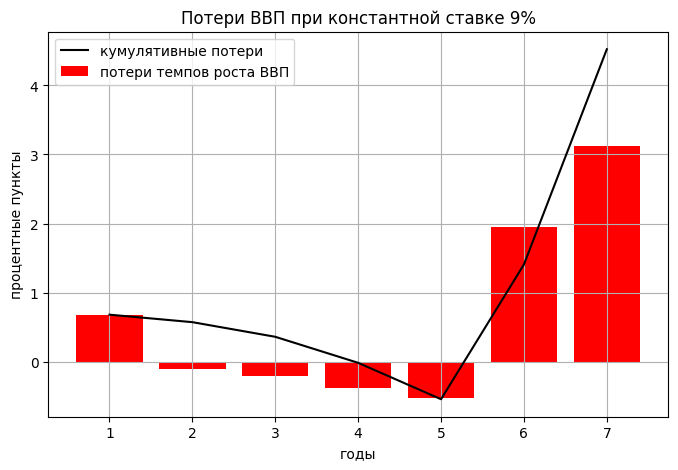

In [2]:
rate = 0.09
scen9 = simulate_scenario(build_scenario_5_strategy(rate=rate))

plot_main_indicators(scen9, 'Константная ставка 9%', do_set_ylim=False)
plot_losses(scen9, 'Потери ВВП при константной ставке 9%')

## Сценарий с константной ставкой 11%

В этом блоке ставка фиксирована на уровне **11%** на всём горизонте.

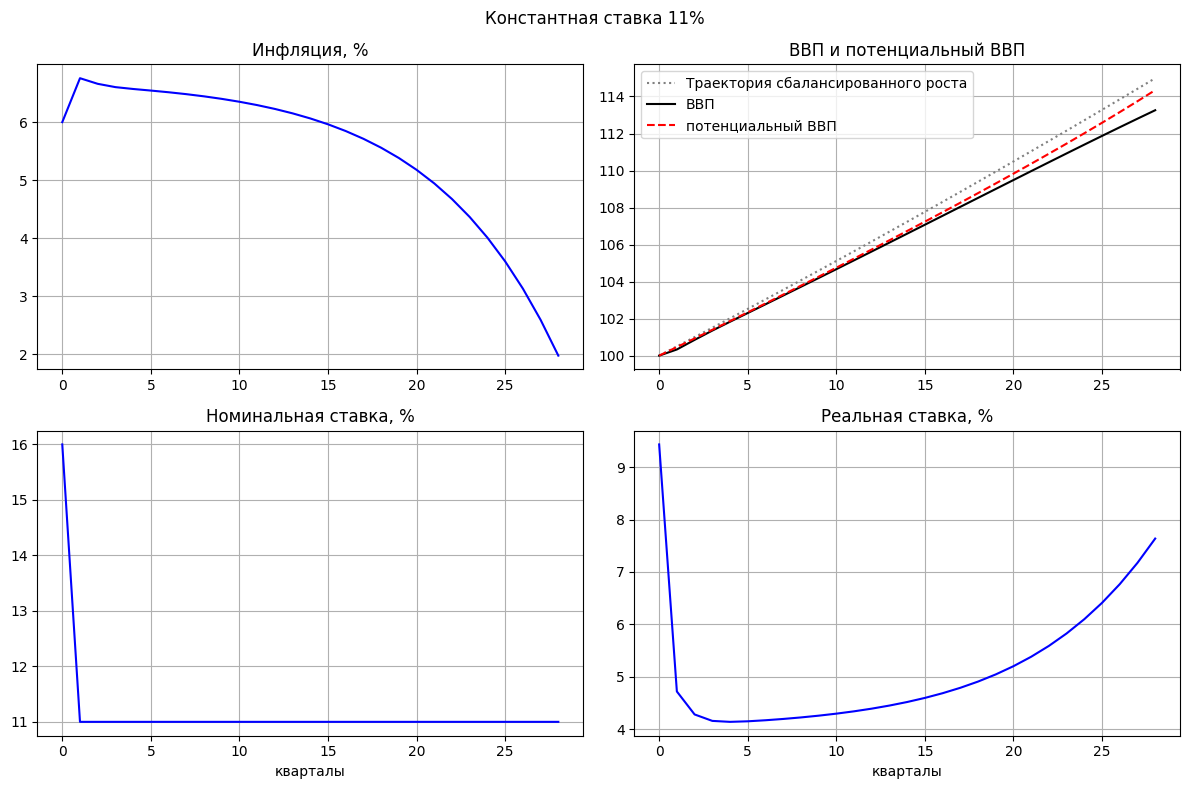

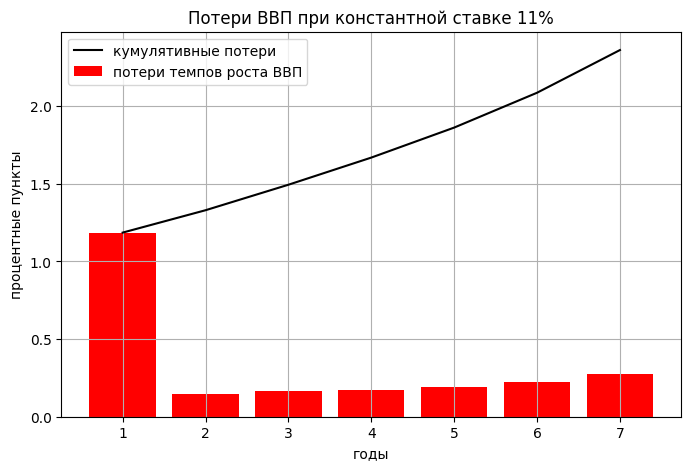

In [3]:
rate = 0.11
scen11 = simulate_scenario(build_scenario_5_strategy(rate=rate))

plot_main_indicators(scen11, 'Константная ставка 11%', do_set_ylim=False)
plot_losses(scen11, 'Потери ВВП при константной ставке 11%')

In [4]:
rate = 0.13
scen5 = simulate_scenario(build_scenario_5_strategy(rate=rate))

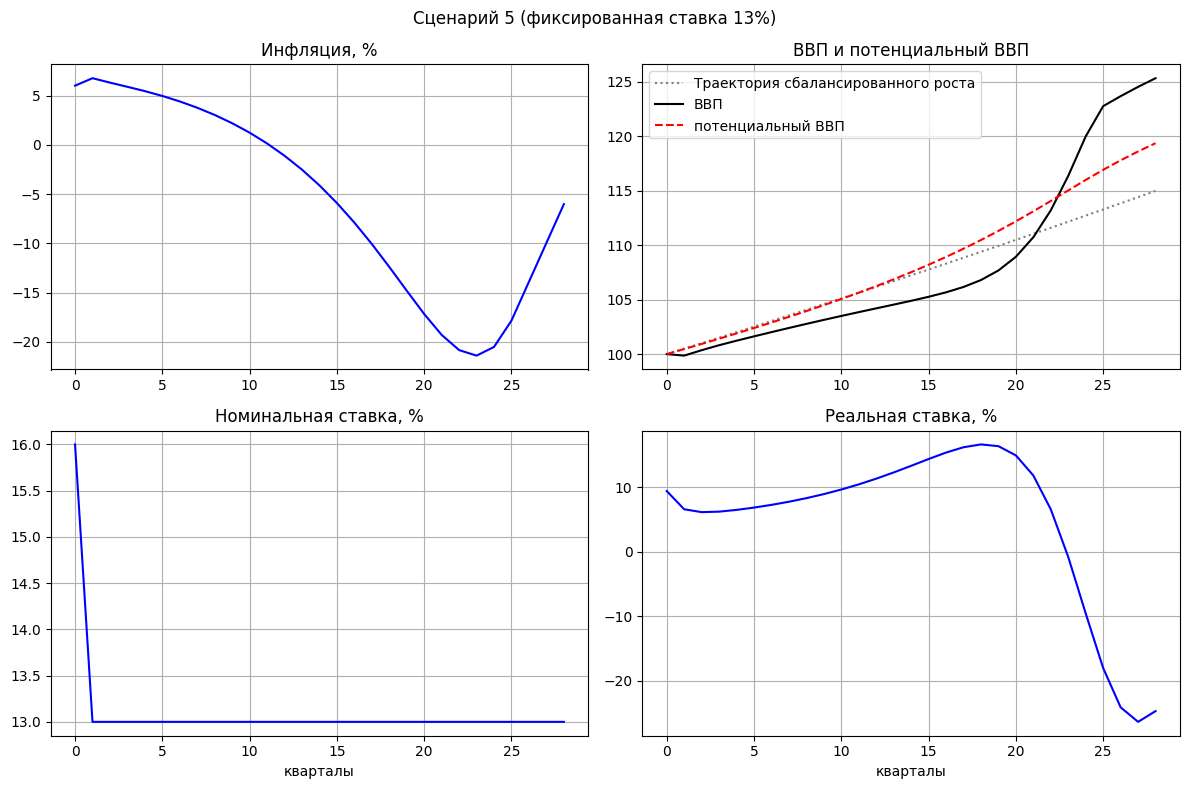

In [5]:
plot_main_indicators(scen5, 'Сценарий 5 (фиксированная ставка 13%)', do_set_ylim=False)

## Сценарий с константной ставкой 16%

В этом блоке ставка фиксирована на уровне **16%** на всём горизонте.

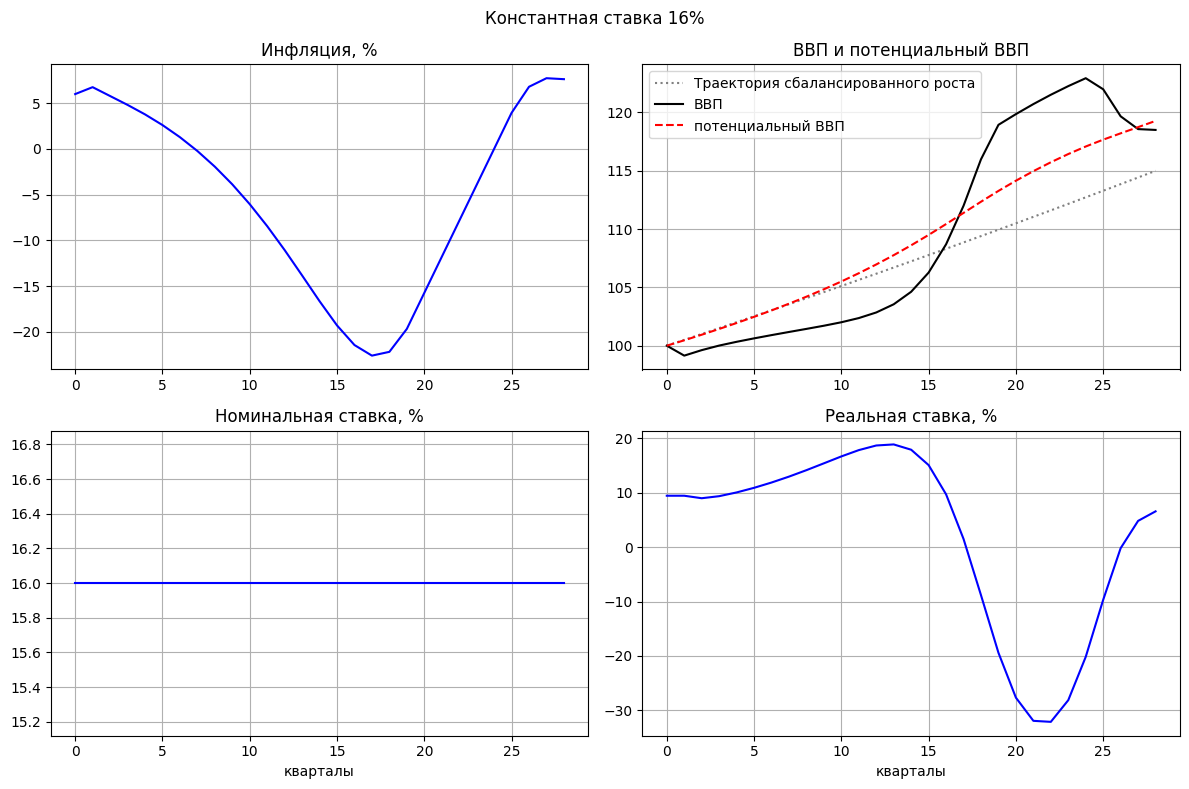

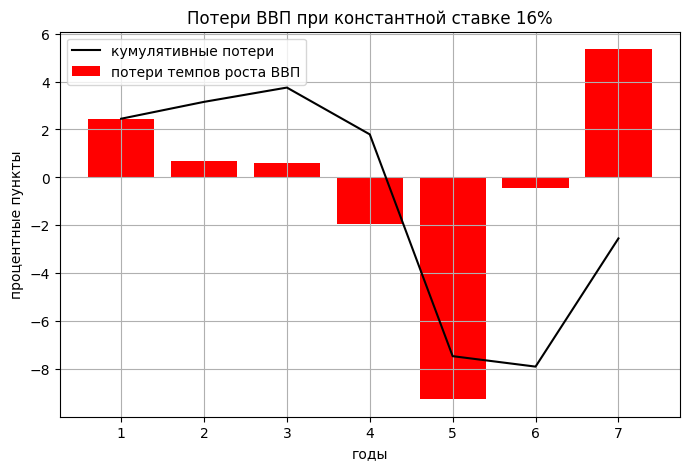

In [6]:
rate = 0.16
scen16 = simulate_scenario(build_scenario_5_strategy(rate=rate))

plot_main_indicators(scen16, 'Константная ставка 16%', do_set_ylim=False)
plot_losses(scen16, 'Потери ВВП при константной ставке 16%')

## Сценарий с константной ставкой 20%

В этом блоке ставка фиксирована на уровне **20%** на всём горизонте.

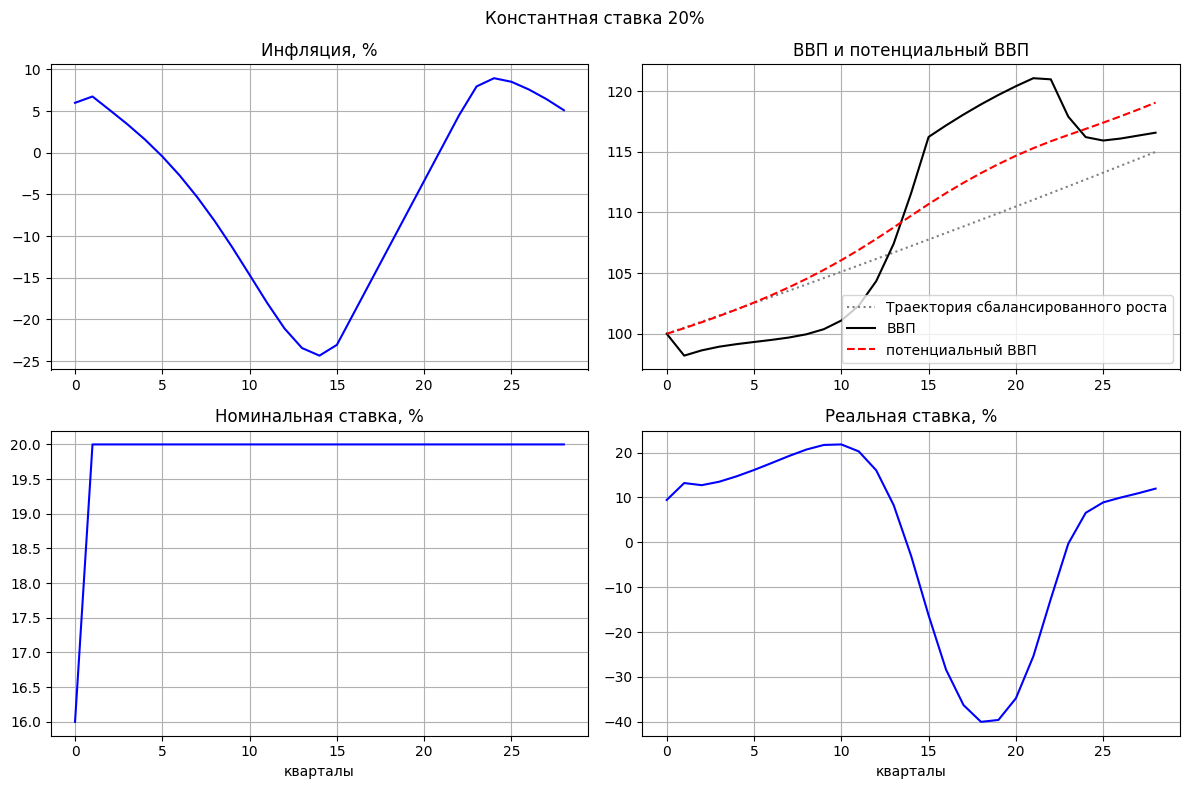

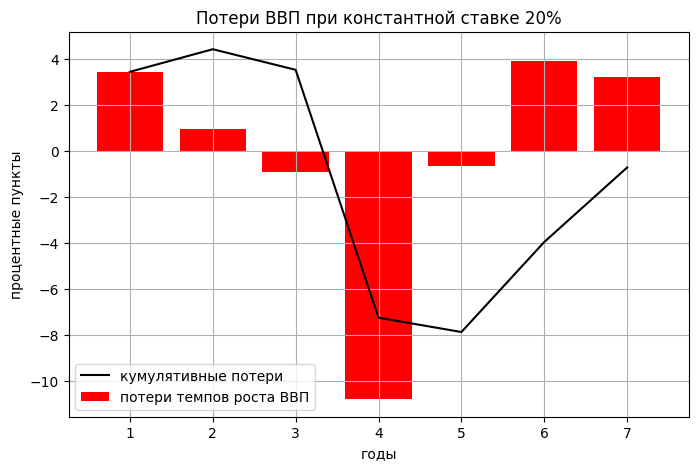

In [7]:
rate = 0.20
scen20 = simulate_scenario(build_scenario_5_strategy(rate=rate))

plot_main_indicators(scen20, 'Константная ставка 20%', do_set_ylim=False)
plot_losses(scen20, 'Потери ВВП при константной ставке 20%')

## Сценарий с константной ставкой 30%

В этом блоке ставка фиксирована на уровне **30%** на всём горизонте.

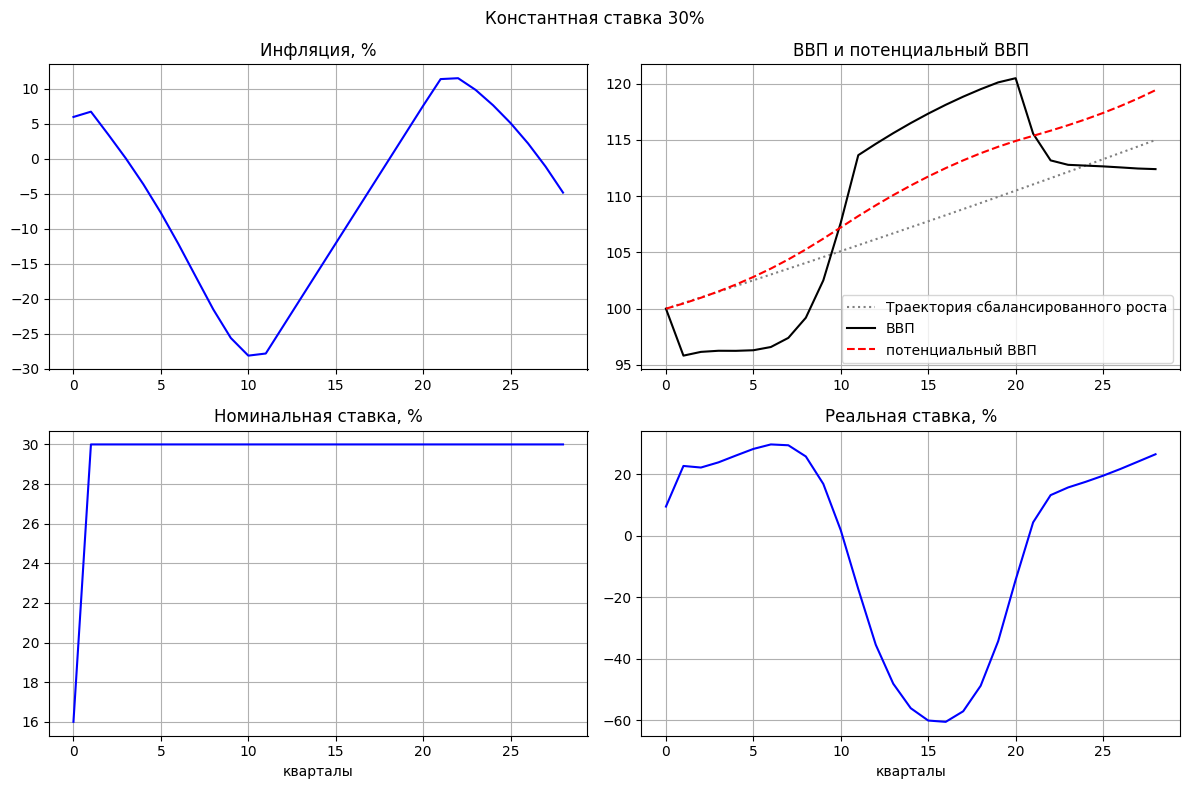

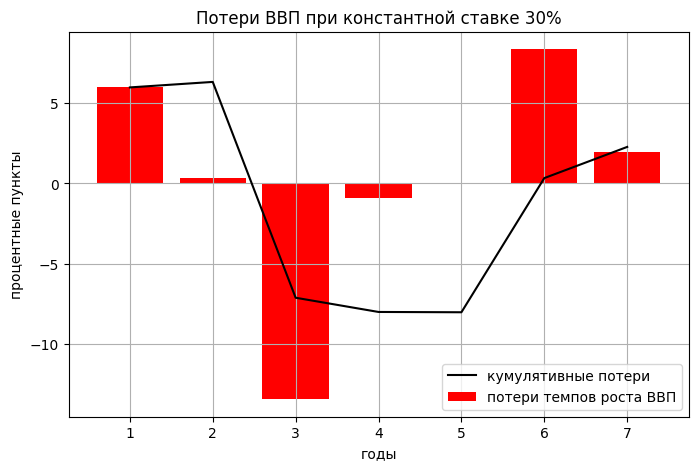

In [8]:
rate = 0.30
scen30 = simulate_scenario(build_scenario_5_strategy(rate=rate))

plot_main_indicators(scen30, 'Константная ставка 30%', do_set_ylim=False)
plot_losses(scen30, 'Потери ВВП при константной ставке 30%')

## Расчёт сценария с двумя периодами константной ставки

Стратегия:
- первые 2 года (8 кварталов) ставка фиксирована на **13%**;
- далее ставка фиксирована на **11%**.

Ниже реализована пользовательская стратегия и построены графики для этого сценария.

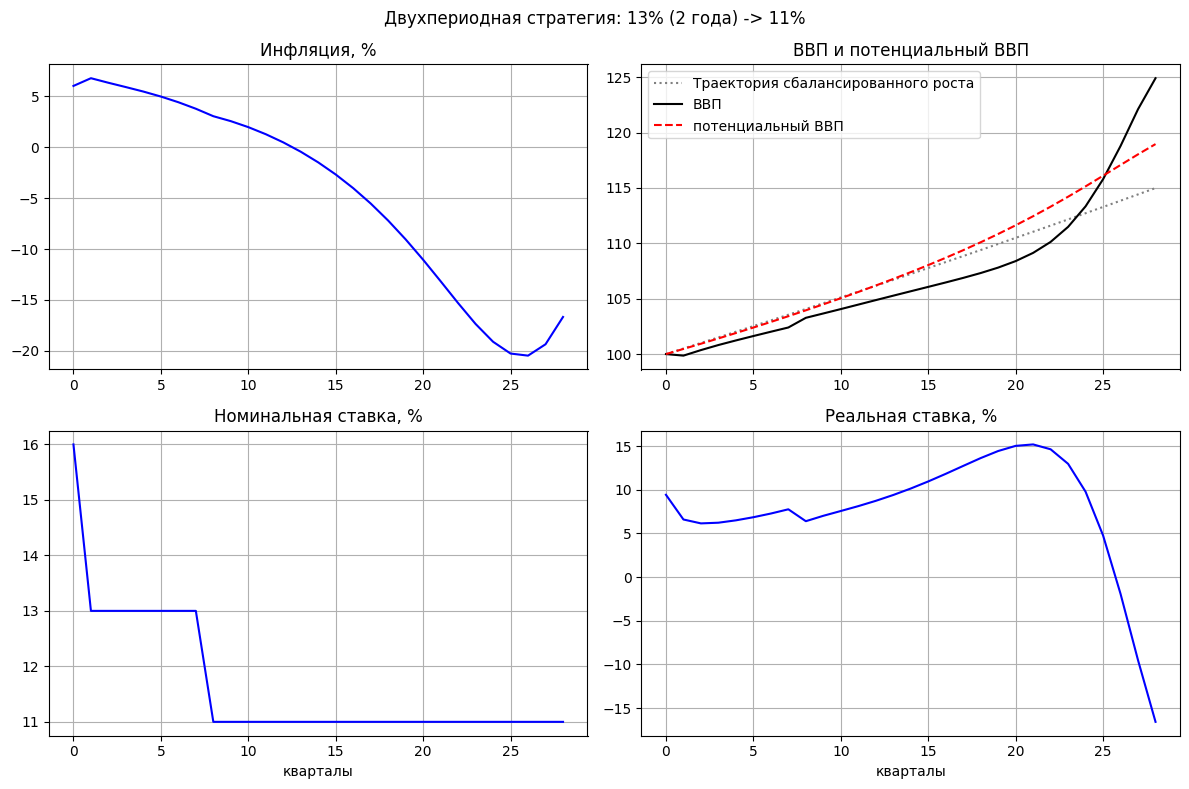

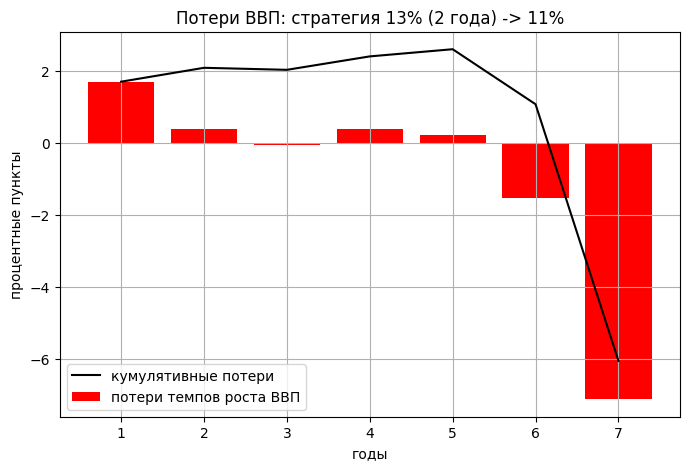

In [9]:
class TwoPhaseConstantRateStrategy:
    """13% первые 8 кварталов, затем 11%."""

    def __init__(self, rate_first: float = 0.13, rate_second: float = 0.11, switch_quarter: int = 8):
        self.rate_first = rate_first
        self.rate_second = rate_second
        self.switch_quarter = switch_quarter

    def get_interest_rate(self, t, pi, x):
        return self.rate_first if t < self.switch_quarter else self.rate_second


strategy_13_to_11 = TwoPhaseConstantRateStrategy()
scen_13_to_11 = simulate_scenario(strategy_13_to_11)

plot_main_indicators(
    scen_13_to_11,
    'Двухпериодная стратегия: 13% (2 года) -> 11%',
    do_set_ylim=False,
)
plot_losses(scen_13_to_11, 'Потери ВВП: стратегия 13% (2 года) -> 11%')